In [1]:
import os
import shutil

# ========== CONFIGURABLE PATHS ==========
# Set these environment variables on Kaggle, or edit defaults for local use.
DATA_DIR       = os.environ.get("DATA_DIR",       "/kaggle/input/datasets/ayakc5013/pemf-data/pemf_data/pictures/modified_pics")
WORK_DIR       = os.environ.get("WORK_DIR",       "/kaggle/working")
FEATURES_DIR   = os.environ.get("FEATURES_DIR",   os.path.join(WORK_DIR, "mobilenetv3L_features_data"))
MODEL_OUT      = os.environ.get("MODEL_OUT",      os.path.join(WORK_DIR, "saved_cnn_lstm.keras"))
MOBILENET_W   = os.environ.get("MOBILENET_W",    "/kaggle/input/mobilenetv3large-imagenet-weights-h5/mobilenetv3large_imagenet.weights.h5")
CKPT_PATH     = os.environ.get("CKPT_PATH",      os.path.join(WORK_DIR, "ckpt.weights.h5"))
# ========== END CONFIG ==========

import os
import shutil
import glob



# Ensure saved model and vocab are in WORK_DIR so your main() will auto-load them.

def ensure_files_in_working(model_filename="saved_cnn_lstm.keras",
                            vocab_filename="label_vocab.npy",
                            download_urls=None):
    """
    Ensure model_filename and vocab_filename exist under /kaggle/working.
    - If already in /kaggle/working, nothing is done.
    - Otherwise first search WORK_DIR for them.
    - If not found and download_urls is provided (dict with keys 'model' and/or 'vocab'),
      attempt to download them to /kaggle/working.
    Returns tuple (model_path, vocab_path) which are paths under /kaggle/working (may be None).
    """
    os.makedirs(WORK_DIR, exist_ok=True)
    wk_model = os.path.join(WORK_DIR, model_filename)
    wk_vocab = os.path.join(WORK_DIR, vocab_filename)

    # If both already present in working -> done
    if os.path.exists(wk_model) and os.path.exists(wk_vocab):
        print("Files already present in /kaggle/working.")
        return wk_model, wk_vocab

    # Search /kaggle/input recursively for model and vocab
    found_model = None
    found_vocab = None

    input_matches_model = glob.glob(os.path.join(WORK_DIR, "**", model_filename), recursive=True)
    if input_matches_model:
        found_model = input_matches_model[0]

    input_matches_vocab = glob.glob(os.path.join(WORK_DIR, "**", vocab_filename), recursive=True)
    if input_matches_vocab:
        found_vocab = input_matches_vocab[0]

    # Copy if found under /kaggle/input
    if found_model:
        shutil.copy(found_model, wk_model)
        print(f"Copied model from {found_model} -> {wk_model}")
    else:
        print(f"No {model_filename} found under /kaggle/input.")

    if found_vocab:
        shutil.copy(found_vocab, wk_vocab)
        print(f"Copied vocab from {found_vocab} -> {wk_vocab}")
    else:
        print(f"No {vocab_filename} found under /kaggle/input.")

    # If not found and download_urls provided, try download
    if (not os.path.exists(wk_model) or not os.path.exists(wk_vocab)) and download_urls:
        import requests
        def download(url, dst):
            print(f"Downloading {url} -> {dst}")
            r = requests.get(url, stream=True)
            r.raise_for_status()
            with open(dst, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)

        if (not os.path.exists(wk_model)) and download_urls.get("model"):
            try:
                download(download_urls["model"], wk_model)
            except Exception as e:
                print("Failed to download model:", e)

        if (not os.path.exists(wk_vocab)) and download_urls.get("vocab"):
            try:
                download(download_urls["vocab"], wk_vocab)
            except Exception as e:
                print("Failed to download vocab:", e)

    # Final existence check
    final_model = wk_model if os.path.exists(wk_model) else None
    final_vocab = wk_vocab if os.path.exists(wk_vocab) else None

    print("Final model path:", final_model)
    print("Final vocab path:", final_vocab)
    return final_model, final_vocab

# Example usage:
# If you added a Kaggle Dataset containing the files, this will find and copy them automatically.
model_path, vocab_path = ensure_files_in_working()

# If you want to download from URLs (e.g., from a personal cloud), pass them:
# urls = {"model": "https://example.com/saved_cnn_lstm.keras", "vocab": "https://example.com/label_vocab.npy"}
# model_path, vocab_path = ensure_files_in_working(download_urls=urls)

Copied model from /kaggle/input/mobilenetweights/mobilenetweights/saved_cnn_lstm.keras -> /kaggle/working/saved_cnn_lstm.keras
Copied vocab from /kaggle/input/mobilenetweights/mobilenetweights/label_vocab.npy -> /kaggle/working/label_vocab.npy
Final model path: /kaggle/working/saved_cnn_lstm.keras
Final vocab path: /kaggle/working/label_vocab.npy


In [8]:
!pip install tensorflow


In [1]:
import os
import keras
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

from collections import Counter
import os, json, numpy as np


2025-10-21 14:40:35.706892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761057635.933788      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761057635.991467      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


['0', '1']
 train data shape: (1754, 20, 960), train labels shape: (1754, 1)
 test data shape: (109, 20, 960), test labels shape: (109, 1)
 validation data shape: (98, 20, 960), validation labels shape: (98, 1)
Computed class weights: {0: 2.002283105022831, 1: 0.6664133738601824}
No label_vocab.npy found at /kaggle/working/label_vocab.npy
Built new model architecture.
No checkpoint weights at /kaggle/working/ckpt.weights.h5
TRAIN=True -> will train (use checkpoint callback to save weights / best model).
Epoch 1/100


2025-10-21 15:11:50.227464: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


218/220 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4677 - loss: 0.7165

2025-10-21 15:11:55.710693: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_accuracy improved from -inf to 0.36735, saving model to /kaggle/working/ckpt.weights.h5
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.4679 - loss: 0.7164 - val_accuracy: 0.3673 - val_loss: 0.7128
Epoch 2/100
218/220 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5290 - loss: 0.6929
Epoch 2: val_accuracy improved from 0.36735 to 0.41837, saving model to /kaggle/working/ckpt.weights.h5
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5288 - loss: 0.6929 - val_accuracy: 0.4184 - val_loss: 0.7113
Epoch 3/100
216/220 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5664 - loss: 0.6922
Epoch 3: val_accuracy improved from 0.41837 to 0.71429, saving model to /kaggle/working/ckpt.weights.h5
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5658 - loss: 0.6922 - val_accuracy: 0.7143 - val_loss: 0.6604
Epoch 4/100
218/220 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5856 - loss: 0.6620
Epoch 4: val_accuracy did not improve from 0.71429
220/220 ━━━━━━━━━━━━━━━━━━

2025-10-21 15:14:50.764022: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


217/220 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4677 - loss: 0.7166

2025-10-21 15:14:56.177762: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4679 - loss: 0.7164 - val_accuracy: 0.3673 - val_loss: 0.7128
Epoch 2/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5288 - loss: 0.6929 - val_accuracy: 0.4184 - val_loss: 0.7113
Epoch 3/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5658 - loss: 0.6922 - val_accuracy: 0.7143 - val_loss: 0.6604
Epoch 4/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5855 - loss: 0.6620 - val_accuracy: 0.4286 - val_loss: 0.7110
Epoch 5/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6404 - loss: 0.6217 - val_accuracy: 0.6429 - val_loss: 0.6343
Epoch 6/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6904 - loss: 0.5833 - val_accuracy: 0.4898 - val_loss: 0.7262
Epoch 7/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6424 - loss: 0.5807 - val_accuracy: 0.5102 - val_loss: 0.6683
Epoch 8/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6697 - loss: 0.5641 - val_accuracy: 0.459

2025-10-21 15:17:49.185792: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


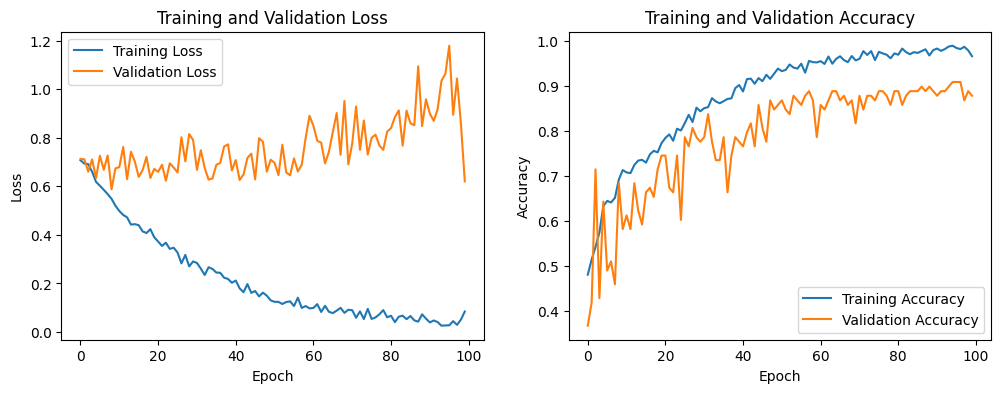

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step
Precision: 0.9397
Recall: 0.9358
F1-score: 0.9369
              precision    recall  f1-score   support

           0       0.83      0.93      0.88        27
           1       0.97      0.94      0.96        82

    accuracy                           0.94       109
   macro avg       0.90      0.93      0.92       109
weighted avg       0.94      0.94      0.94       109



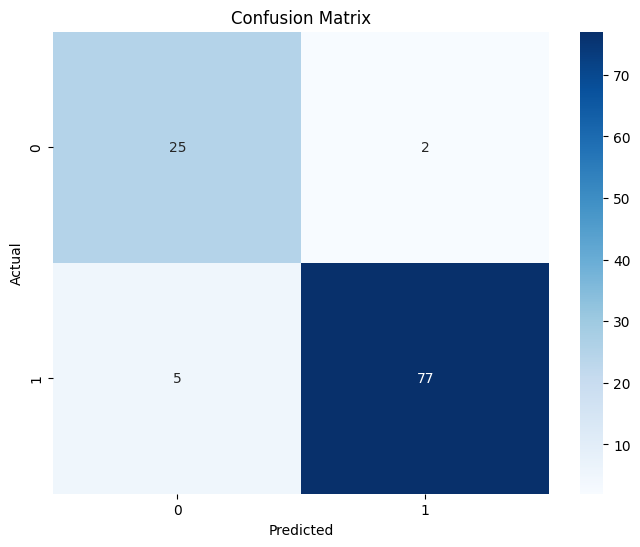

In [5]:
def main():
    with tf.device('/device:GPU:0'):
        tf.random.set_seed(2001)
        np.random.seed(2001)
        extract_features = True

        folder_path = DATA_DIR
        output_folder_path = 'FEATURES_DIR'

        os.makedirs(output_folder_path, exist_ok=True)
        train_features = os.path.join(output_folder_path, 'train_features.npy')
        train_labels = os.path.join(output_folder_path, 'train_labels.npy')
        val_features = os.path.join(output_folder_path, 'val_features.npy')
        val_labels = os.path.join(output_folder_path, 'val_labels.npy')
        test_features = os.path.join(output_folder_path, 'test_features.npy')
        test_labels = os.path.join(output_folder_path, 'test_labels.npy')
           # Only extract features if not all files exist
        feature_files = [

            test_features, test_labels,
            train_features, train_labels,
            val_features ,val_labels
        ]
        extract_features = not all(os.path.exists(f) for f in feature_files)
        IMG_SIZE = 224
        NUM_FRAMES = 20
        NUM_FEATURES = 960 #change 1 

        EPOCHS = 100
        BATCH_SIZE = 8

        INITIAL_LEARNING_RATE = 0.001
        DECAY_STEPS = 1000
        DECAY_RATE = 0.96

        if extract_features:
            def get_data(folder_path):
                video_paths = []
                labels = []
                df = pd.DataFrame(columns=['video_path', 'tag'])

                for subject in os.listdir(folder_path):
                    subject_path = os.path.join(folder_path, subject)
                    if os.path.isdir(subject_path):
                        for stimulus in os.listdir(subject_path):
                            stimulus_path = os.path.join(subject_path, stimulus)
                            if os.path.isdir(stimulus_path):
                                for folder in os.listdir(stimulus_path):
                                    frames_path = os.path.join(stimulus_path, folder)
                                    video_paths.append(frames_path)

                                    if 'Neutral' in stimulus:
                                        label = 'Nopain'
                                    elif 'Posed Pain' in stimulus:
                                        label = 'Pain'
                                    elif 'Algometer Pain' in stimulus:
                                        label = 'Pain'
                                    else:
                                        label = 'Pain'

                                    labels.append(label)

                df['video_path'] = video_paths
                df['tag'] = labels
                return df

            data = get_data(folder_path)

            print(data.head(5))
            print(len(data['video_path']))
            print(data["tag"].value_counts())

            # Split the data into test, train, and validation sets
            train_df, test_df = train_test_split(data, test_size=0.1, random_state=42, stratify=data['tag'])
            train_df, val_df = train_test_split(train_df, test_size=0.1)

            print('---------TRAIN-------------', train_df.shape)
            print('---------test-------------', test_df.shape)
            print('---------VAL--------------', val_df.shape)

            # Get the class names
            label_processor = keras.layers.StringLookup(
                num_oov_indices=0, vocabulary=np.unique(train_df["tag"])
            )
            print(label_processor.get_vocabulary())


            #########################################################################
            # --- save test_df and supporting artifacts for reproducibility ---
            
            out_dir = "FEATURES_DIR"  # <-- set to the directory where you saved test_features.npy
            os.makedirs(out_dir, exist_ok=True)
            
            # save the DataFrame (rows correspond to the saved test_features.npy order)
            test_df.to_csv(os.path.join(out_dir, "test_df.csv"), index=False)
            
            # save the explicit list of video paths (ensures exact ordering)
            np.save(os.path.join(out_dir, "test_paths.npy"), test_df["video_path"].values)
            
            # if you have test_labels as a separate array, save that too (optional if already saved)
            # np.save(os.path.join(out_dir, "test_labels.npy"), np.asarray(test_labels))
            
            # save a tiny metadata file (optional but handy)
            meta = {
                "saved_by": "main()",
                "out_dir": out_dir,
                "rows": int(len(test_df)),
                # include any split params you want to record
                "random_state": 42,
                "test_size": 0.1,
            }
            with open(os.path.join(out_dir, "metadata.json"), "w") as f:
                json.dump(meta, f, indent=2)
            
            print(f"Saved test_df.csv and test_paths.npy to: {out_dir}")
            # --- end save block ---

            # Load frames
            def load_frames_from_folder(folder_path):
                frame_files = sorted([os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))])
                frames = []
                for frame_file in frame_files:
                    frame = cv2.imread(frame_file)
                    if frame is not None:
                        # Check if the image is grayscale
                        if len(frame.shape) == 2 or frame.shape[2] == 1:
                            frame = np.stack((frame,) * 3, axis=-1)
                        else:
                            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

                        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
                        frame = tf.cast(frame, tf.float32) / 255.0
                        # Standardize the image
                        frame = (frame - tf.constant([0.485, 0.456, 0.406])) / tf.constant([0.229, 0.224, 0.225])
                        frames.append(frame)
                        if len(frames) == NUM_FRAMES:
                            break
                    else:
                        print(f"Could not read frame: {frame_file}")
                if len(frames) != NUM_FRAMES:
                    print(f"Folder {folder_path} does not have enough frames. Only {len(frames)} were loaded.")
                return np.array(frames)

            def generate_random_params():
                params = {
                    "flip": tf.random.uniform([], 0, 1) > 0.5,
                    "brightness": tf.random.uniform([], 0.0, 0.4),
                    "contrast": tf.random.uniform([], 0.8, 1.2),
                    "saturation": tf.random.uniform([], 0.8, 1.2),
                    "hue": tf.random.uniform([], 0.0, 0.1),
                    "apply_affine": tf.random.uniform([], 0, 1) > 0.3,
                    "scale": tf.random.uniform([], 0.8, 1.0),
                    "translate": tf.random.uniform(shape=[2], minval=-0.2, maxval=0.2),
                    "rotation": tf.random.uniform([], -15, 15),
                    "apply_erasing": tf.random.uniform([], 0, 1) > 0.5,
                }
                return params

            # Function for translation
            def affine_translate(image, tx, ty):
                # Ensure image has 4 dimensions [batch, height, width, channels]
                original_shape = tf.shape(image)
                original_rank = tf.rank(image)
                
                # Handle different input shapes
                if original_rank == 3:  # [height, width, channels]
                    image = tf.expand_dims(image, 0)
                elif original_rank == 2:  # [height, width]
                    image = tf.expand_dims(image, 0)
                    image = tf.expand_dims(image, -1)
                    
                # Prepare transformation matrix
                transform = [1, 0, tx, 0, 1, ty, 0, 0]
                transform = tf.convert_to_tensor(transform, dtype=tf.float32)
                transform = tf.reshape(transform, [1, 8])
                
                # Apply transformation
                output = tf.raw_ops.ImageProjectiveTransformV3(
                    images=image,
                    transforms=transform,
                    output_shape=tf.shape(image)[1:3],  # [height, width]
                    interpolation="BILINEAR",
                    fill_mode="REFLECT",
                    fill_value=0
                )
                
                # Restore original rank
                if original_rank == 3:
                    output = tf.squeeze(output, 0)
                elif original_rank == 2:
                    output = tf.squeeze(output, -1)
                    output = tf.squeeze(output, 0)
                    
                return output

            # Function for rotation
            def rotate_image(image, angle_rad):
                # 1. Make sure it's a Tensor
                image = tf.convert_to_tensor(image, dtype=tf.float32)
            
                # 2. Add batch dimension if needed
                if len(image.shape) == 3:
                    image = tf.expand_dims(image, axis=0)  # (1, H, W, C)
            
                h, w = tf.shape(image)[1], tf.shape(image)[2]
                cx, cy = tf.cast(w, tf.float32) / 2.0, tf.cast(h, tf.float32) / 2.0
                cos_a = tf.math.cos(angle_rad)
                sin_a = tf.math.sin(angle_rad)
            
                a0 = cos_a
                a1 = -sin_a
                a2 = cx - cx * cos_a + cy * sin_a
                a3 = sin_a
                a4 = cos_a
                a5 = cy - cx * sin_a - cy * cos_a
            
                transform = tf.convert_to_tensor([a0, a1, a2, a3, a4, a5, 0, 0], dtype=tf.float32)
                transform = tf.reshape(transform, [1, 8])
            
                output = tf.raw_ops.ImageProjectiveTransformV3(
                    images=image,
                    transforms=transform,
                    output_shape=tf.shape(image)[1:3],
                    interpolation="BILINEAR",
                    fill_mode='REFLECT',
                    fill_value=0.0
                )
            
                # 3. Remove batch dimension after processing
                output = tf.squeeze(output, axis=0)
            
                return output

            
                        # Random cutout function
            def random_cutout(image, mask_size, mask_value=0):
                if len(image.shape) == 3:
                   image = tf.expand_dims(image, 0)
                img_shape = tf.shape(image)
                batch_size = img_shape[0]
                height = img_shape[1]
                width = img_shape[2]
                channels = img_shape[3]
            
                cutout_shape = mask_size
            
                offset_height = tf.random.uniform([], 0, height - cutout_shape[0] + 1, dtype=tf.int32)
                offset_width = tf.random.uniform([], 0, width - cutout_shape[1] + 1, dtype=tf.int32)
            
                lower_pad = offset_height
                upper_pad = height - cutout_shape[0] - offset_height
                left_pad = offset_width
                right_pad = width - cutout_shape[1] - offset_width
            
                # Create mask with shape [height, width, 1]
                mask = tf.ones([cutout_shape[0], cutout_shape[1], 1], dtype=image.dtype) * mask_value
                mask = tf.pad(mask, [[lower_pad, upper_pad], [left_pad, right_pad], [0, 0]], constant_values=1)
            
                # Expand to [1, height, width, 1] if necessary
                mask = tf.expand_dims(mask, axis=0)
            
                # Broadcast to match [1, height, width, channels]
                mask = tf.tile(mask, [batch_size, 1, 1, channels])
            
                return image * mask

            def augment_frame(frame, params):
                if len(frame.shape) == 3:
                    frame = tf.expand_dims(frame, axis=0)

                if params["flip"]:
                    frame = tf.image.flip_left_right(frame)
                frame = tf.image.adjust_brightness(frame, params["brightness"])
                frame = tf.image.random_contrast(frame, lower=0.8, upper=params["contrast"])
                frame = tf.image.random_saturation(frame, lower=0.8, upper=params["saturation"])
                frame = tf.image.random_hue(frame, max_delta=params["hue"])
                if params["apply_affine"]:
                    frame = affine_translate(frame, params["translate"][0] * IMG_SIZE, params["translate"][1] * IMG_SIZE)
                    angle_rad = params["rotation"] * (np.pi / 180)
                    frame = rotate_image(frame, angle_rad)

                crop_size = tf.random.uniform([], minval=int(IMG_SIZE * params["scale"]), maxval=IMG_SIZE, dtype=tf.int32)
                frame = tf.image.resize_with_crop_or_pad(frame, crop_size, crop_size)
                frame = tf.image.resize(frame, [IMG_SIZE, IMG_SIZE])

                if params["apply_erasing"]:
                    erase_area = tf.random.uniform([], 0.02, 0.4) * IMG_SIZE * IMG_SIZE
                    erase_aspect_ratio = tf.random.uniform([], 0.3, 3.3)
                    erase_height = tf.sqrt(erase_area / erase_aspect_ratio)
                    erase_width = erase_area / erase_height

                    erase_height = tf.cast(tf.math.ceil(erase_height / 2) * 2, tf.int32)
                    erase_width = tf.cast(tf.math.ceil(erase_width / 2) * 2, tf.int32)
                    erase_height = tf.minimum(erase_height, IMG_SIZE)
                    erase_width = tf.minimum(erase_width, IMG_SIZE)
                    frame = random_cutout(frame, [erase_height, erase_width], mask_value=0)

                if frame.shape[0] == 1:
                    frame = tf.squeeze(frame, axis=0)
                return frame

            def augment_frames(frames):
                params = generate_random_params()
                augmented_frames = [augment_frame(frame, params) for frame in frames]
                return np.array(augmented_frames)

            def save_features_labels(features, labels, features_path, labels_path):
                features_dir = os.path.dirname(features_path)
                labels_dir = os.path.dirname(labels_path)

                if not os.path.exists(features_dir):
                    os.makedirs(features_dir)
                if not os.path.exists(labels_dir):
                    os.makedirs(labels_dir)

                np.save(features_path, features)
                np.save(labels_path, labels)

            def _to_tensor_frames(frames):
                # Convert frames to a [T, H, W, 3] float32 tensor for batched model.predict
                import tensorflow as tf
                import numpy as np
                if isinstance(frames, np.ndarray) and frames.dtype == object:
                    frames = tf.stack([tf.convert_to_tensor(f, dtype=tf.float32) for f in frames], axis=0)
                elif isinstance(frames, np.ndarray):
                    frames = tf.convert_to_tensor(frames, dtype=tf.float32)
                else:
                    frames = tf.convert_to_tensor(frames, dtype=tf.float32)
                return frames

            def prepare_all_videos(
                df,
                features_path,
                labels_path,
                augment_plan=None,   # e.g., {"Nopain": 2, "Pain": 1}
                augment_prob=None,   # e.g., {"Pain": 0.2} -> ~20% of Pain items get 1 extra copy
                rng_seed=42
                ):
                """
                Extract features for all videos. Optionally add augmented copies per class.
            
                augment_plan: dict label_text -> integer copies per sample
                augment_prob: dict label_text -> probability [0..1] to apply each copy
                """
                import numpy as np
                import random
                rnd = random.Random(rng_seed)
            
                video_paths = df["video_path"].tolist()
                labels_text = df["tag"].values
                labels_ids = tf.convert_to_tensor(label_processor(labels_text[..., None])).numpy()
            
                augment_plan = augment_plan or {}
                augment_prob = augment_prob or {}
            
                features_list = []
                labels_list = []
            
                for i, (path, label_txt, label_id) in enumerate(zip(video_paths, labels_text, labels_ids)):
                    frames = load_frames_from_folder(path)     # returns array of per-frame tensors
                    frames = _to_tensor_frames(frames)         # [T,H,W,3]
                    if int(frames.shape[0]) != NUM_FRAMES:
                        print(f"Video {path} does not have enough frames.")
                        continue
            
                    # Original features (batched over frames)
                    feats = feature_extractor.predict(frames, verbose=0)     # [T, NUM_FEATURES]
                    features_list.append(feats[None, ...])                   # [1, T, F]
                    labels_list.append(label_id)
            
                    # Augmented copies per class
                    copies = int(augment_plan.get(label_txt, 0))
                    if copies > 0:
                        p = float(augment_prob.get(label_txt, 1.0))
                        for _ in range(copies):
                            if rnd.random() <= p:
                                aug_frames = augment_frames(frames)          # returns array of tensors
                                aug_frames = _to_tensor_frames(aug_frames)   # [T,H,W,3]
                                feats_aug = feature_extractor.predict(aug_frames, verbose=0)
                                features_list.append(feats_aug[None, ...])
                                labels_list.append(label_id)
            
                    if (i + 1) % 25 == 0 or (i + 1) == len(video_paths):
                        print(f"Processed {i + 1}/{len(video_paths)} videos")
            
                # Stack and save
                if features_list:
                    frame_features = np.concatenate(features_list, axis=0)
                    all_labels = np.asarray(labels_list, dtype=np.int64)
                else:
                    frame_features = np.zeros((0, NUM_FRAMES, NUM_FEATURES), dtype="float32")
                    all_labels = np.zeros((0,), dtype=np.int64)
            
                os.makedirs(os.path.dirname(features_path), exist_ok=True)
                np.save(features_path, frame_features)
                np.save(labels_path, all_labels)
                return frame_features, all_labels
            def build_feature_extractor():
                feature_extractor = keras.applications.MobileNetV3Large(
                    weights=MOBILENET_W,  # change 2
                    include_top=False,
                    pooling="avg",
                    input_shape=(IMG_SIZE, IMG_SIZE, 3),
                )
                inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
                outputs = feature_extractor(inputs)
                return tf.keras.Model(inputs, outputs, name="feature_extractor")

            feature_extractor = build_feature_extractor()

            # Validation / Test: no augmentation
            val_data, val_labels = prepare_all_videos(val_df, val_features, val_labels, augment_plan={}, augment_prob={})
            test_data, test_labels = prepare_all_videos(test_df, test_features, test_labels, augment_plan={}, augment_prob={})

            # Train augment plan (equal for both classes)
            augment_plan = {"Nopain": 1, "Pain": 1}
            augment_prob = {"Nopain": 1.0, "Pain": 1.0}
            
            train_data, train_labels = prepare_all_videos(
                train_df, train_features, train_labels,
                augment_plan=augment_plan, augment_prob=augment_prob
            )

            
            # Train: Pain is ~3x Nopain
            # Balance by adding 2 copies to Nopain; add 1 light copy to ~20% of Pain
           # augment_plan = {"Nopain": 2, "Pain": 1}
           # augment_prob = {"Pain": 0.2}
           # train_data, train_labels = prepare_all_videos(
               # train_df, train_features, train_labels,
               # augment_plan=augment_plan, augment_prob=augment_prob
           # )
        else:
            def load_features_labels(features_path, labels_path):
                features = np.load(features_path)
                labels = np.load(labels_path)
                return features, labels

            train_data, train_labels = load_features_labels(train_features, train_labels)
            val_data, val_labels = load_features_labels(val_features, val_labels)
            test_data, test_labels = load_features_labels(test_features, test_labels)

            all_labels = np.concatenate([train_labels, val_labels, test_labels]).astype(str)
            label_processor = keras.layers.StringLookup(
                num_oov_indices=0, vocabulary=np.unique(all_labels)
            )
            print(label_processor.get_vocabulary())

        print(f" train data shape: {train_data.shape}, train labels shape: {train_labels.shape}")
        print(f" test data shape: {test_data.shape}, test labels shape: {test_labels.shape}")
        print(f" validation data shape: {val_data.shape}, validation labels shape: {val_labels.shape}")

        def compute_class_weights(labels):
            labels_flat = labels.flatten()
            class_weights = compute_class_weight(
                class_weight='balanced',
                classes=np.unique(labels_flat),
                y=labels_flat
            )
            class_weight_dict = dict(enumerate(class_weights))
            return class_weight_dict

        class_weights = compute_class_weights(train_labels)
        print("Computed class weights:", class_weights)

        def build_cnn_lstm_model(num_classes=2):
            cnn_input = tf.keras.Input(shape=(NUM_FRAMES, NUM_FEATURES))
            lstm_out = tf.keras.layers.LSTM(128, return_sequences=True)(cnn_input)
            lstm_out = tf.keras.layers.LSTM(64)(lstm_out)
            x = tf.keras.layers.Dense(128, activation='relu')(lstm_out)
            output = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
            model = tf.keras.Model(inputs=cnn_input, outputs=output)

            lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=INITIAL_LEARNING_RATE,
                decay_steps=DECAY_STEPS,
                decay_rate=DECAY_RATE,
                staircase=True
            )
            model.compile(
                loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                metrics=["accuracy"]
            )
            return model

        def build_cnn_Bilstm_model(num_classes=2):
            cnn_input = tf.keras.Input(shape=(NUM_FRAMES, NUM_FEATURES))
            bilstm_out = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True))(cnn_input)
            bilstm_out = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64))(bilstm_out)
            x = tf.keras.layers.Dense(128, activation='relu')(bilstm_out)
            output = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
            model = tf.keras.Model(inputs=cnn_input, outputs=output)

            lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=INITIAL_LEARNING_RATE,
                decay_steps=DECAY_STEPS,
                decay_rate=DECAY_RATE,
                staircase=True
            )
            model.compile(
                loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                metrics=["accuracy"]
            )
            return model

        def build_cnn_stacked_lstm_att_model(num_classes=2):
            cnn_input = tf.keras.Input(shape=(NUM_FRAMES, NUM_FEATURES))
            lstm_out = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True))(cnn_input)
            lstm_out = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(lstm_out)
            lstm_out = tf.keras.layers.LSTM(64)(lstm_out)
            attention = tf.keras.layers.Attention()([lstm_out, lstm_out])
            attention = tf.keras.layers.Flatten()(attention)
            x = tf.keras.layers.Dense(128, activation='relu')(lstm_out)
            x = tf.keras.layers.Dropout(rate=0.25)(x)
            output = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
            model = tf.keras.Model(inputs=cnn_input, outputs=output)

            lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=INITIAL_LEARNING_RATE,
                decay_steps=DECAY_STEPS,
                decay_rate=DECAY_RATE,
                staircase=True
            )
            model.compile(
                loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                metrics=["accuracy"]
            )
            return model

        def build_cnn_lstm_model_with_attention(num_classes=2):
            cnn_input = tf.keras.Input(shape=(NUM_FRAMES, NUM_FEATURES))
            lstm_out = tf.keras.layers.LSTM(128, return_sequences=True)(cnn_input)
            query = lstm_out
            value = lstm_out
            attention_out, attention_scores = tf.keras.layers.Attention()([query, value], return_attention_scores=True)
            lstm_out = tf.keras.layers.LSTM(64)(attention_out)
            x = tf.keras.layers.Dense(128, activation='relu')(lstm_out)
            output = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
            model = tf.keras.Model(inputs=cnn_input, outputs=output)

            lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=INITIAL_LEARNING_RATE,
                decay_steps=DECAY_STEPS,
                decay_rate=DECAY_RATE,
                staircase=True
            )
            model.compile(
                loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                metrics=["accuracy"]
            )
            return model
            # Model: LSTM with attention, deterministic initializers
        def build_cnn_lstm_model_with_attention_determinism(num_classes=2, seed=42):
            import tensorflow as tf
            import random
            random.seed(seed)
            np.random.seed(seed)
            tf.random.set_seed(seed)
            tf.keras.utils.set_random_seed(seed)
            tf.config.experimental.enable_op_determinism()
        
            cnn_input = tf.keras.Input(shape=(NUM_FRAMES, NUM_FEATURES))
            lstm_out = tf.keras.layers.LSTM(
                128, return_sequences=True,
                kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed),
                recurrent_initializer=tf.keras.initializers.Orthogonal(seed=seed)
            )(cnn_input)
        
            attention_out, _ = tf.keras.layers.Attention()([lstm_out, lstm_out], return_attention_scores=True)
        
            lstm_out2 = tf.keras.layers.LSTM(
                64,
                kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed+1),
                recurrent_initializer=tf.keras.initializers.Orthogonal(seed=seed+1)
            )(attention_out)
        
            x = tf.keras.layers.Dense(
                128, activation='relu',
                kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed+2)
            )(lstm_out2)
        
            output = tf.keras.layers.Dense(
                num_classes, activation='softmax',
                kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed+3)
            )(x)
        
            model = tf.keras.Model(inputs=cnn_input, outputs=output)
        
            lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=INITIAL_LEARNING_RATE,
                decay_steps=DECAY_STEPS,
                decay_rate=DECAY_RATE,
                staircase=True
            )
            model.compile(
                loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                metrics=["accuracy"]
            )
            return model

        ########################################################
        # --- Paste this after you have train_data/val_data/test_data and (optionally) label_processor ready ---


        # Paths (adjust if your filenames are different)
        VOCAB_SAVE_PATH = os.path.join(WORK_DIR, "label_vocab.npy")
        # Try several possible saved-model names you might have used
        POSSIBLE_MODEL_PATHS = [
            MODEL_OUT,   # recommended Keras format
            os.path.join(WORK_DIR, "saved_cnn_lstm_model"),   # alternative dir name
            os.path.join(WORK_DIR, "saved_cnn_lstm")          # another variant
        ]
        CKPT_WEIGHTS_PATH = CKPT_PATH  # your weights-only checkpoint (optional)
        
        # If you want to reuse saved model/weights without retraining, set TRAIN = False
        TRAIN = True
        
        # 1) Load label vocabulary if saved
        if os.path.exists(VOCAB_SAVE_PATH):
            try:
                vocab = np.load(VOCAB_SAVE_PATH, allow_pickle=True)
                label_processor = tf.keras.layers.StringLookup(num_oov_indices=0, vocabulary=vocab)
                print("Loaded label vocab from", VOCAB_SAVE_PATH, "->", label_processor.get_vocabulary())
            except Exception as e:
                print("Failed to load label_vocab.npy:", e)
        else:
            print("No label_vocab.npy found at", VOCAB_SAVE_PATH)
            # If your code already set label_processor earlier (e.g., from train_df),
            # you can continue. Otherwise you must build label_processor before building model.
        
        # 2) Try to find a full saved model (preferred)
        model_loaded = False
        loaded_model_path = None
        for p in POSSIBLE_MODEL_PATHS:
            if os.path.exists(p):
                try:
                    print("Found saved model at", p, "-> loading full model with tf.keras.models.load_model()")
                    cnn_lstm_model = tf.keras.models.load_model(p, compile=True)
                    model_loaded = True
                    loaded_model_path = p
                    print("Full model loaded from:", p)
                    break
                except Exception as e:
                    print("Attempt to load full model from", p, "failed:", e)
                    # keep trying other candidates
        
        # 3) If full model not loaded, build the model and optionally load weights
        if not model_loaded:
            # Ensure label_processor exists so we can set correct num_classes
            try:
                num_classes = len(label_processor.get_vocabulary())
            except Exception as e:
                raise RuntimeError("label_processor not defined. Either load label_vocab.npy or create label_processor before building the model.") from e
        
            # Build model using your deterministic builder (must match the saved architecture if you'll load weights)
            cnn_lstm_model = build_cnn_lstm_model_with_attention_determinism(num_classes)
            print("Built new model architecture.")
        
            # If you have a weights-only checkpoint, try to load it
            if os.path.exists(CKPT_WEIGHTS_PATH):
                try:
                    cnn_lstm_model.load_weights(CKPT_WEIGHTS_PATH)
                    print("Loaded weights from", CKPT_WEIGHTS_PATH)
                except Exception as e:
                    print("Could not load weights from", CKPT_WEIGHTS_PATH, "-", e)
            else:
                print("No checkpoint weights at", CKPT_WEIGHTS_PATH)

        # 4) If TRAIN==False skip training and evaluate/predict if test data exists
        if not TRAIN:
            print("TRAIN=False -> skipping training.")
            # Ensure test features exist: if not present in memory, try loading from .npy files you used earlier
            try:
                _ = test_data  # test_data should be present in this scope if you created it earlier
                _ = test_labels
            except NameError:
                # try loading from the .npy file paths you saved earlier
                saved_test_feat = "os.path.join(FEATURES_DIR, "test_features.npy")"
                saved_test_labels = "os.path.join(FEATURES_DIR, "test_labels.npy")"
                if os.path.exists(saved_test_feat) and os.path.exists(saved_test_labels):
                    test_data = np.load(saved_test_feat, allow_pickle=True)
                    test_labels = np.load(saved_test_labels, allow_pickle=True)
                    print("Loaded test_data/test_labels from disk:", saved_test_feat)
                else:
                    print("No test_data/test_labels found in memory or on disk. Cannot evaluate/predict now.")
        
            # Evaluate if test_data/test_labels are present
            if 'test_data' in globals() and 'test_labels' in globals():
                try:
                    loss, acc = cnn_lstm_model.evaluate(test_data, test_labels, verbose=1)
                    print(f"Evaluation: loss={loss:.4f}, acc={acc*100:.2f}%")
                except Exception as e:
                    print("Evaluation failed:", e)
        
            # Example predict usage (only if test_data available)
            if 'test_data' in globals():
                try:
                    preds = cnn_lstm_model.predict(test_data, verbose=1)
                    pred_labels = np.argmax(preds, axis=1) if preds.ndim > 1 else (preds >= 0.5).astype(int)
                    print("Predictions ready (example):", pred_labels[:10])
                except Exception as e:
                    print("Predict failed:", e)
        
        else:
            # TRAIN == True: train as usual, with callbacks to save best weights
            print("TRAIN=True -> will train (use checkpoint callback to save weights / best model).")
            callbacks = []
            try:
                callbacks.append(checkpoint)  # reuse your checkpoint callback if defined earlier
            except NameError:
                # fallback checkpoint (weights only)
                callbacks.append(tf.keras.callbacks.ModelCheckpoint(
                    filepath=CKPT_WEIGHTS_PATH,
                    monitor="val_accuracy",
                    save_best_only=True,
                    save_weights_only=True,
                    verbose=1,
                    mode="max"
                ))
        
            history = cnn_lstm_model.fit(
                train_data,
                train_labels,
                validation_data=(val_data, val_labels),
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                class_weight=class_weights,
                callbacks=callbacks,
            )
        
            # after training save full model and vocab for later reuse
            try:
                save_path = MODEL_OUT
                cnn_lstm_model.save(save_path)
                print("Saved full model to", save_path)
            except Exception as e:
                print("Failed to save full model:", e)
        
            try:
                vocab = label_processor.get_vocabulary()
                np.save(VOCAB_SAVE_PATH, vocab)
                print("Saved label vocab to", VOCAB_SAVE_PATH, "->", vocab)
            except Exception as e:
                print("Failed to save label vocab:", e)
        
        # --- end of block ---
      
        def plot_history(history):
            plt.figure(figsize=(12, 4))
            plt.subplot(1, 2, 1)
            plt.plot(history.history['loss'], label='Training Loss')
            plt.plot(history.history['val_loss'], label='Validation Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.title('Training and Validation Loss')

            plt.subplot(1, 2, 2)
            plt.plot(history.history['accuracy'], label='Training Accuracy')
            plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.title('Training and Validation Accuracy')
            plt.show()

        cnn_lstm_model = build_cnn_lstm_model_with_attention_determinism(len(label_processor.get_vocabulary()))
        filepath = os.environ.get("FEATURES_PATH", "/kaggle/working/features")
        checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=CKPT_PATH, monitor="val_accuracy", save_best_only=True, mode='max',save_weights_only=True, verbose=1)

        history = cnn_lstm_model.fit(
            train_data,
            train_labels,
            validation_data=(val_data, val_labels),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            class_weight=class_weights,
        )

        _, accuracy = cnn_lstm_model.evaluate(test_data, test_labels)
        print(f"Test accuracy: {round(accuracy * 100, 2)}%")
        plot_history(history)

        test_predictions = cnn_lstm_model.predict(test_data)
        test_predictions_labels = np.argmax(test_predictions, axis=1)
        conf_matrix = confusion_matrix(test_labels, test_predictions_labels)

        precision = precision_score(test_labels, test_predictions_labels, average='weighted')
        recall = recall_score(test_labels, test_predictions_labels, average='weighted')
        f1 = f1_score(test_labels, test_predictions_labels, average='weighted')

        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-score: {f1:.4f}")

        report = classification_report(test_labels, test_predictions_labels, target_names=label_processor.get_vocabulary())
        print(report)

        def plot_confusion_matrix(cm, class_names):
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.title('Confusion Matrix')
            plt.show()

        plot_confusion_matrix(conf_matrix, label_processor.get_vocabulary())

if __name__ == '__main__':
    main()

In [6]:
# Paste this into a new notebook cell (Python) right after you run the notebook cell that trains/evaluates `cnn_lstm_model`.
# It will create a CSV with per-sequence results and print simple dataset counts.
#
# Requirements / assumptions (based on your notebook):
# - test_df is the pandas DataFrame containing the test video rows (columns: 'video_path' and 'tag').
# - test_data is the numpy array of shape [N_sequences, NUM_FRAMES, NUM_FEATURES] used by the model.
# - test_labels is the array of true numeric labels for each sequence (or you can use test_df['tag'] for textual labels).
# - cnn_lstm_model is the trained Keras model.
# - label_processor exists (optional) and may be used to recover vocabulary.
#
# The CSV will contain:
# subject_id, stimulus_type, sequence_name, true_label (0=no pain, 1=pain),
# predicted_label (0/1), prob_pain, prob_nopain
#
# If anything above is missing this cell will attempt to give a helpful error.

import os
import pandas as pd
import numpy as np
import os
import pandas as pd
import numpy as np
import tensorflow as tf

art_dir = FEATURES_DIR
csv_path = os.path.join(art_dir, "test_df.csv")
feat_path = os.path.join(art_dir, "test_features.npy")
model_path = os.path.join(art_dir, "saved_cnn_lstm.keras")  # adjust if different

# load test_df
if "test_df" not in globals():
    if os.path.exists(csv_path):
        test_df = pd.read_csv(csv_path).reset_index(drop=True)
        print(f"Loaded test_df ({len(test_df)} rows) from: {csv_path}")
        if "video_path" not in test_df.columns:
            print("Warning: 'video_path' column not found. Columns:", list(test_df.columns))
    else:
        raise RuntimeError(f"test_df.csv not found at: {csv_path}")

# load test_features -> test_data
if "test_data" not in globals():
    if os.path.exists(feat_path):
        test_data = np.load(feat_path, allow_pickle=True)
        print("Loaded test_data from:", feat_path, "shape:", getattr(test_data, "shape", None))
    else:
        raise RuntimeError(f"test_features.npy not found at: {feat_path}")

# optionally load model if not already in memory
if "cnn_lstm_model" not in globals():
    if os.path.exists(model_path):
        cnn_lstm_model = tf.keras.models.load_model(model_path, compile=True)
        print("Loaded model from:", model_path)
    else:
        print("Saved model not found at:", model_path, "- you can load it later if needed")
# ---- START: add these lines at the VERY TOP of the "last cell" ----

# 1) load full saved model (adjust path if your file name is different)
cnn_lstm_model = tf.keras.models.load_model(MODEL_OUT, compile=True)

# 2) ensure test_data/test_labels exist: if missing in memory, try to load from disk .npy files
if 'test_data' not in globals() or 'test_labels' not in globals():
    saved_test_feat = os.path.join(FEATURES_DIR, "test_features.npy")
    saved_test_labels = os.path.join(FEATURES_DIR, "test_labels.npy")
    if os.path.exists(saved_test_feat) and os.path.exists(saved_test_labels):
        test_data = np.load(saved_test_feat, allow_pickle=True)
        test_labels = np.load(saved_test_labels, allow_pickle=True)
        print("Loaded test_data/test_labels from disk:", saved_test_feat)
    else:
        raise RuntimeError(
            "test_data/test_labels not found in memory or on disk.\n"
            "Either re-run the feature-extraction cells (so test_data/test_df are created),\n"
            "or make sure the files exist at: " + saved_test_feat + " and " + saved_test_labels
        )
# ---- END: added block ----
# ---- Adjust output path here if you want somewhere else ----
out_csv_path = "test_sequence_predictions.csv"
cnn_lstm_model = tf.keras.models.load_model(MODEL_OUT, compile=True)
# Helper to extract path parts robustly
def parse_sequence_path(path):
    """
    Return (subject_id, stimulus_type, sequence_name) from a path such as:
      .../<subject>/<stimulus>/<sequence_folder>
    Works by splitting path and taking last three components. If path is shorter,
    it will attempt sensible fallbacks.
    """
    p = os.path.normpath(path)
    parts = p.split(os.sep)
    if len(parts) >= 3:
        subject = parts[-3]
        stimulus = parts[-2]
        seq = parts[-1]
    elif len(parts) == 2:
        subject = parts[-2]
        stimulus = parts[-1]
        seq = ""
    elif len(parts) == 1:
        subject = parts[0]
        stimulus = ""
        seq = ""
    else:
        subject = ""
        stimulus = ""
        seq = ""
    return subject, stimulus, seq

# BEGIN main logic (with safety checks)
try:
    # Required objects from notebook
    _ = cnn_lstm_model
    _ = test_data
    _ = test_df
except NameError as e:
    missing = str(e).split("'")[1]
    raise RuntimeError(
        f"Could not find variable '{missing}' in the notebook namespace. "
        "Make sure you run the training/extraction cells so that cnn_lstm_model, test_data and test_df exist."
    )

# 1) Get sequence-level predictions (probabilities)
preds = cnn_lstm_model.predict(test_data, verbose=0)  # shape: (N_sequences, num_classes)

# If model outputs a single scalar per sample (binary single-logit), convert accordingly
if preds.ndim == 1:
    # treat as probability of positive class
    prob_pain = preds
    prob_nopain = 1.0 - prob_pain
    predicted_label = (prob_pain >= 0.5).astype(int)
else:
    # preds is (N, C)
    # figure out which index corresponds to "Pain" if possible
    pain_index = None
    try:
        vocab = label_processor.get_vocabulary()  # may be strings like ['Nopain','Pain']
    except Exception:
        vocab = None

    if vocab:
        # try a few heuristics
        try:
            if "Pain" in vocab:
                pain_index = int(vocab.index("Pain"))
            elif "pain" in vocab:
                pain_index = int(vocab.index("pain"))
            elif "Nopain" in vocab and "Pain" in vocab:
                pain_index = int(vocab.index("Pain"))
            # If vocabulary contains numeric strings '0'/'1', fallback below
        except Exception:
            pain_index = None

    if pain_index is None:
        # fallback: assume class index 1 == Pain (common when labels encoded [0=no pain,1=pain])
        if preds.shape[1] >= 2:
            pain_index = 1
        else:
            # single-class softmax? treat first as nopain and fallback
            pain_index = 0

    prob_pain = preds[:, pain_index]
    # If there are exactly two classes, compute nopain as the other column if present
    if preds.shape[1] == 2:
        prob_nopain = preds[:, 1 - pain_index]
    else:
        # otherwise compute 1 - prob_pain (not perfect for >2 classes, but reasonable fallback)
        prob_nopain = 1.0 - prob_pain

    predicted_label = (prob_pain >= 0.5).astype(int)

# 2) Build the output DataFrame aligned with test_df order
df_test = test_df.reset_index(drop=True).copy()
N_df = len(df_test)
N_preds = prob_pain.shape[0]
if N_df != N_preds:
    # warn but proceed by using min length
    print(f"Warning: test_df rows ({N_df}) != number of predictions ({N_preds}). "
          "Truncating to the smaller of the two.")
    n = min(N_df, N_preds)
    df_test = df_test.iloc[:n].reset_index(drop=True)
    prob_pain = prob_pain[:n]
    prob_nopain = prob_nopain[:n]
    predicted_label = predicted_label[:n]

# Extract parts from paths and compute true_label binary
subjects = []
stimuli = []
seq_names = []
true_label_binary = []

for path, tag in zip(df_test["video_path"].tolist(), df_test["tag"].tolist()):
    subject, stimulus, seq = parse_sequence_path(path)
    subjects.append(subject)
    stimuli.append(stimulus)
    seq_names.append(seq)
    # original dataset assigned: 'Neutral' -> 'Nopain', others -> 'Pain'
    # But to be robust, if tag already contains Nopain/Pain use that
    if isinstance(tag, str):
        if "Neutral" in tag or tag.lower().startswith("no") or tag.lower().startswith("nopain"):
            true_label_binary.append(0)
        elif "Pain" in tag or tag.lower().startswith("pain") or tag.lower().startswith("posed") or "algometer" in tag.lower() or "laser" in tag.lower():
            true_label_binary.append(1)
        else:
            # fallback: if tag is 'Nopain' or 'Pain'
            if tag.lower() == "nopain":
                true_label_binary.append(0)
            elif tag.lower() == "pain":
                true_label_binary.append(1)
            else:
                # unknown -> try to map '0'/'1'
                if tag in ("0", "1"):
                    true_label_binary.append(int(tag))
                else:
                    # default to Pain if uncertain
                    true_label_binary.append(1)
    else:
        # numeric tag
        try:
            true_label_binary.append(int(tag))
        except Exception:
            true_label_binary.append(1)

out_df = pd.DataFrame({
    "subject_id": subjects,
    "stimulus_type": stimuli,
    "sequence_name": seq_names,
    "sequence_path": df_test["video_path"].tolist(),
    "true_label": true_label_binary,
    "predicted_label": predicted_label.astype(int),
    "prob_pain": prob_pain.astype(float),
    "prob_nopain": prob_nopain.astype(float),
})

# Reorder columns for readability
out_df = out_df[[
    "subject_id", "stimulus_type", "sequence_name", "sequence_path",
    "true_label", "predicted_label", "prob_pain", "prob_nopain"
]]

# Save CSV
out_df.to_csv(out_csv_path, index=False)
print(f"Saved test sequence predictions to: {out_csv_path}")

# 3) Print simple dataset summary: how many subjects in train/test and pain/no-pain counts
def summary_counts(df, name):
    if df is None:
        print(f"{name}: DataFrame not available.")
        return
    # get unique subjects
    subjects = []
    for p in df["video_path"].tolist():
        s, _, _ = parse_sequence_path(p)
        subjects.append(s)
    n_subjects = len(pd.unique(subjects))
    # pain / nopain counts using tag column if present
    if "tag" in df.columns:
        vc = df["tag"].value_counts()
        # try to normalize names to Pain/Nopain
        pain_count = vc.get("Pain", vc.get("pain", 0)) + vc.get("Posed Pain", 0) + vc.get("Algometer Pain", 0) + vc.get("Laser Pain", 0)
        nopain_count = vc.get("Nopain", vc.get("Neutral", vc.get("neutral", 0)))
        # fallback if not present
        if pain_count == 0 and nopain_count == 0:
            # maybe tags are numeric encoded already
            try:
                numeric = df["tag"].astype(int)
                pain_count = int((numeric == 1).sum())
                nopain_count = int((numeric == 0).sum())
            except Exception:
                pain_count = int(vc.sum())
                nopain_count = 0
    else:
        pain_count = nopain_count = None

    print(f"{name}: subjects = {n_subjects}")
    if pain_count is not None:
        print(f"{name}: pain samples = {pain_count}, no-pain samples = {nopain_count}")
    else:
        print(f"{name}: cannot compute pain/no-pain (missing 'tag' column).")

# Try to print counts for train and test (if available)
if "train_df" in globals():
    summary_counts(train_df, "Train set")
else:
    print("Train set (train_df) not found in notebook namespace.")

summary_counts(test_df, "Test set")

# Also print totals from the generated CSV (for double check)
print("\nCSV summary (from saved file):")
print(out_df[["true_label", "predicted_label"]].agg(["sum", "count"]).transpose())

# If you want the full DataFrame preview:
print(f"\nPreview of output (first 10 rows):\n{out_df.head(10)}")

# End of cell

Saved model not found at: /kaggle/working/mobilenetv3L_features_data/saved_cnn_lstm.keras - you can load it later if needed
Loaded test_data/test_labels from disk: /kaggle/working/mobilenetv3L_features_data/test_features.npy


2025-10-21 15:20:48.778933: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Saved test sequence predictions to: test_sequence_predictions.csv
Train set (train_df) not found in notebook namespace.
Test set: subjects = 57
Test set: pain samples = 82, no-pain samples = 27

CSV summary (from saved file):
                 sum  count
true_label        82    109
predicted_label   79    109

Preview of output (first 10 rows):
  subject_id   stimulus_type       sequence_name  \
0       S043      Posed Pain           BW frames   
1       S029      Posed Pain           BW frames   
2       S027      Posed Pain           BW frames   
3       S055      Posed Pain      BW oval frames   
4       S068         Neutral      BW oval frames   
5       S017         Neutral       Colour frames   
6       S058  Algometer Pain           BW frames   
7       S044      Laser Pain      BW oval frames   
8       S050         Neutral      BW oval frames   
9       S065         Neutral  Colour oval frames   

                                       sequence_path  true_label  \
0  /kaggle/in

/tmp/ipykernel_37/742199764.py:251: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  n_subjects = len(pd.unique(subjects))
